In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from csv_reader import read_csv
from copy import deepcopy as copy
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BATCH_SIZE = 1
PARAMS_START = 2 + BATCH_SIZE
N_PAIRWISE_RULES_PER_TYPE = 12 * 2
N_SUMMED_WEIGHT_RULES_PER_TYPE = 4
N_THREE_FACTOR_RULES_PER_TYPE = 8
N_RULES = 3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE) + 2 * N_THREE_FACTOR_RULES_PER_TYPE

CELL_TYPE_1_SIZE = 5

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS_NO_HET_SHORT = [
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001051_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_13:34:30.296805_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001052_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_13:34:30.296808_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001053_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_14:18:32.696893_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001054_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_14:20:39.706146_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001055_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_13:34:54.899000_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001056_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_13:34:54.898937_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001057_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_14:54:22.373381_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001058_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_14:54:22.373378_run_None',
    'sims_out/rule_dropout_n5_short_min_pactive_0p25_diag_test_001059_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_13:29:25.604457_run_None',
]

DATA_PATHS_NO_HET_LONG = [
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001100_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:33:01.657158_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001101_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:33:01.657164_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001102_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:33:01.657163_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001103_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:36:07.983647_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001105_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:36:07.980233_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001106_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:36:51.757038_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001107_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:36:51.757034_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001108_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:36:51.757036_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001110_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:33:23.958586_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001111_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:33:25.583257_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001112_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:36:06.477281_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001118_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:36:06.477286_run_None',
    'sims_out/rule_dropout_n5_long_min_pactive_0p25_diag_small_bump_test_001119_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-15_16:36:06.477284_run_None',
]

rules_to_dropout = np.concatenate([
    np.arange(N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE),
    np.arange(
        3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE),
        3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE)
        + N_THREE_FACTOR_RULES_PER_TYPE,
    ),
])

In [7]:
rule_names = [ # Define labels for all rules to be run during simulations
	r'',
	r'$y$',
	r'$x$',
	r'$y^2$',
	r'$x^2$',
	r'$y^3$',
	r'$x^3$',
	r'$y^4$',
	r'$x^4$',
	r'$x \, y$',
	r'$x \, \tilde{y}$',
	r'$\tilde{x} \, y$',

	r'$w$',
	r'$w y$',
	r'$w x$',
	r'$w y^2$',
	r'$w x^2$',
	r'$w y^3$',
	r'$w x^3$',
	r'$w y^4$',
	r'$w x^4$',
	r'$w x \, y$',
	r'$w x \, \tilde{y}$',
	r'$w \tilde{x} \, y$',

	r'$\Sigma_k w_{kj}$',
    r'$w \Sigma_k w_{kj}$',
	r'$\Sigma_k w_{ik}$',
    r'$w \Sigma_k w_{ik}$',
]

# rule_names = [
# 	[r'$HD \rightarrow HD$ ' + r_name for r_name in rule_names],
# 	[r'$HD \rightarrow HR$ ' + r_name for r_name in rule_names],
# 	[r'$HR \rightarrow HD$ ' + r_name for r_name in rule_names],
# ]

rule_names = [
	rule_names,
    rule_names,
    rule_names,
]

rule_names_tripartite = [
	r'$\tilde{y} \tilde{z}$',
    r'$x \tilde{y} \tilde{z}$',
	r'$\tilde{x} \tilde{z}$',
	r'$\tilde{x} y \tilde{z}$',

	r'$w \tilde{y} \tilde{z}$',
    r'$w x \tilde{y} \tilde{z}$',
	r'$w \tilde{x} \tilde{z}$',
	r'$w \tilde{x} y \tilde{z}$',
]

rule_names += [
	[r_name for r_name in rule_names_tripartite],
	[r_name for r_name in rule_names_tripartite],
]


rule_names = [r for rs in rule_names for r in rs]
rule_names = np.array(rule_names, dtype=object)

In [8]:
print(rule_names)

['' '$y$' '$x$' '$y^2$' '$x^2$' '$y^3$' '$x^3$' '$y^4$' '$x^4$'
 '$x \\, y$' '$x \\, \\tilde{y}$' '$\\tilde{x} \\, y$' '$w$' '$w y$'
 '$w x$' '$w y^2$' '$w x^2$' '$w y^3$' '$w x^3$' '$w y^4$' '$w x^4$'
 '$w x \\, y$' '$w x \\, \\tilde{y}$' '$w \\tilde{x} \\, y$'
 '$\\Sigma_k w_{kj}$' '$w \\Sigma_k w_{kj}$' '$\\Sigma_k w_{ik}$'
 '$w \\Sigma_k w_{ik}$' '' '$y$' '$x$' '$y^2$' '$x^2$' '$y^3$' '$x^3$'
 '$y^4$' '$x^4$' '$x \\, y$' '$x \\, \\tilde{y}$' '$\\tilde{x} \\, y$'
 '$w$' '$w y$' '$w x$' '$w y^2$' '$w x^2$' '$w y^3$' '$w x^3$' '$w y^4$'
 '$w x^4$' '$w x \\, y$' '$w x \\, \\tilde{y}$' '$w \\tilde{x} \\, y$'
 '$\\Sigma_k w_{kj}$' '$w \\Sigma_k w_{kj}$' '$\\Sigma_k w_{ik}$'
 '$w \\Sigma_k w_{ik}$' '' '$y$' '$x$' '$y^2$' '$x^2$' '$y^3$' '$x^3$'
 '$y^4$' '$x^4$' '$x \\, y$' '$x \\, \\tilde{y}$' '$\\tilde{x} \\, y$'
 '$w$' '$w y$' '$w x$' '$w y^2$' '$w x^2$' '$w y^3$' '$w x^3$' '$w y^4$'
 '$w x^4$' '$w x \\, y$' '$w x \\, \\tilde{y}$' '$w \\tilde{x} \\, y$'
 '$\\Sigma_k w_{kj}$' '$w \\Sigma

In [9]:
def load_coefs(df):
    o = read_csv(os.path.join(df, 'train_data.csv'), read_header=False)
    coefs = np.array(o.iloc[0, PARAMS_START: PARAMS_START + N_RULES])
    return coefs

def load_all_coefs(dfs):
    return np.asarray([
        load_coefs(df)
        for df in dfs
    ])

def load_losses(df):
    o = read_csv(os.path.join(df, 'train_data.csv'), read_header=False)

    losses = np.array(o.iloc[:, 1])
    return losses

def make_loss_plots(dfs, num_terms=36, vmax=500):
    all_losses = []
    all_coefs = []
    for df in dfs:
        losses = load_losses(df)
        
        if len(losses) < 30 * (num_terms + 1):
            continue
            
        losses_for_term_dropouts = []
        for i in range(num_terms + 1):
            losses_for_term_dropouts.append(losses[30 * i: 30 * (i+1)])
        all_losses.append(losses_for_term_dropouts)

        coefs = load_coefs(df)
        all_coefs.append(coefs)
    
    all_losses = np.array(all_losses)
    all_coefs = np.array(all_coefs)

    fig, axs = plt.subplots(1, 1, figsize=(3, 1))
    for i in range(all_losses.shape[0]):
        axs.scatter([i] * 30, all_losses[i, 0, :], alpha=0.1)
        print(np.mean(all_losses[i, 0, :]), '+/-', np.std(all_losses[i, 0, :]))
    axs.set_ylim(0)
    axs.set_xlabel('Rule number')
    axs.set_ylabel('Loss')
    format_plot(axs)
    
    fig, ax = plt.subplots(1, 1, figsize=(0.33 * all_losses.shape[0], 8))

    mat = (
        np.median(all_losses, axis=2)[:, 1:]
        - np.median(all_losses, axis=2)[:, 0][:, None]
    )
    
    sns.heatmap(
        mat.T,
        ax=ax,
        cmap='Blues',
        vmax=vmax,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / all_losses.shape[0], pad=0.06),
    )
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)
    
    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)

    fig, ax = plt.subplots(1, 1, figsize=(0.33 * all_losses.shape[0], 8))

    all_coefs = all_coefs[:, rules_to_dropout]

    sns.heatmap(
        (mat * np.where(all_coefs > 0, 1, -1)).T,
        ax=ax,
        cmap=sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True),
        vmax=vmax,
        vmin=-vmax,
        cbar=True,
        cbar_kws=dict(fraction=0.05 * 9 / all_losses.shape[0], pad=0.06),
    )
    
    ax.set_yticks(np.arange(num_terms) + 0.5)
    ax.set_yticklabels(rule_names[rules_to_dropout[:num_terms]], rotation=0)
    
    format_plot(ax, topspine=True, rightspine=True)
    format_plot(ax.collections[0].colorbar.ax, topspine=True, rightspine=True)    

174.67815430333627 +/- 30.397815816461776
191.74674116041447 +/- 43.99888511905354
167.61087235618888 +/- 22.73831709510698
175.34854799330512 +/- 38.86973676765184
180.79776456415235 +/- 30.016028605754286
181.25688539649084 +/- 22.302408966328063
178.74883657889535 +/- 20.787320575145287
164.05309744003904 +/- 25.74607405404407
166.1524916187561 +/- 21.40654249083853


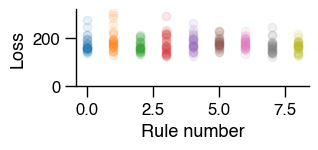

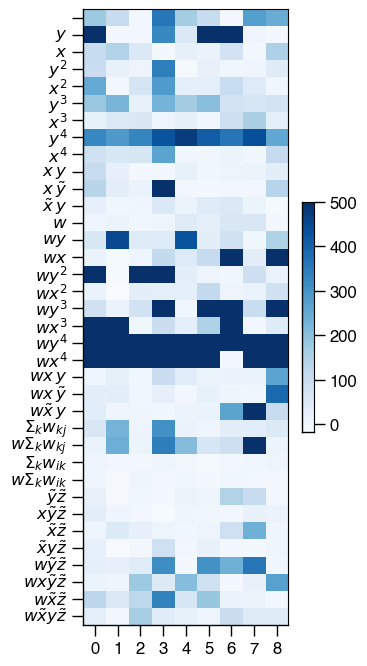

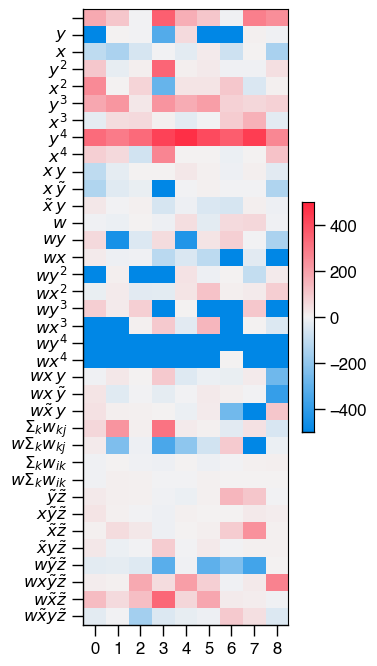

In [10]:
make_loss_plots(DATA_PATHS_NO_HET_SHORT, num_terms=36)

239.983085304367 +/- 31.799950881401138
227.45510778296048 +/- 28.21165534188373
217.11350715770692 +/- 29.64309066419508
218.6287080671961 +/- 73.19136790963499
245.61048443723698 +/- 38.92579575309442
222.3744270811778 +/- 32.61402650698024
233.5608747655004 +/- 38.72028699941721
216.7156321605168 +/- 30.713595895855317
227.15494502195136 +/- 36.5965805845651
245.2350299380229 +/- 32.00014664492218
234.79150103686462 +/- 38.052642143217696
216.48621700677853 +/- 22.488290557808764
134.80378517840023 +/- 17.329693106067413


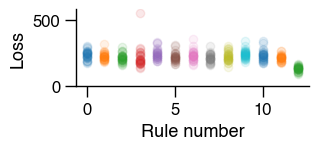

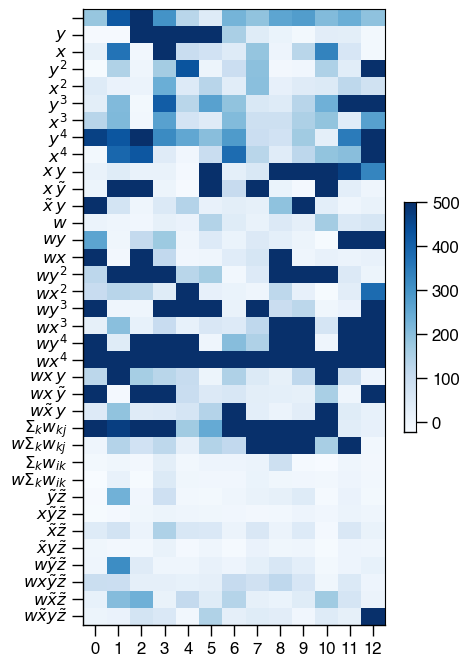

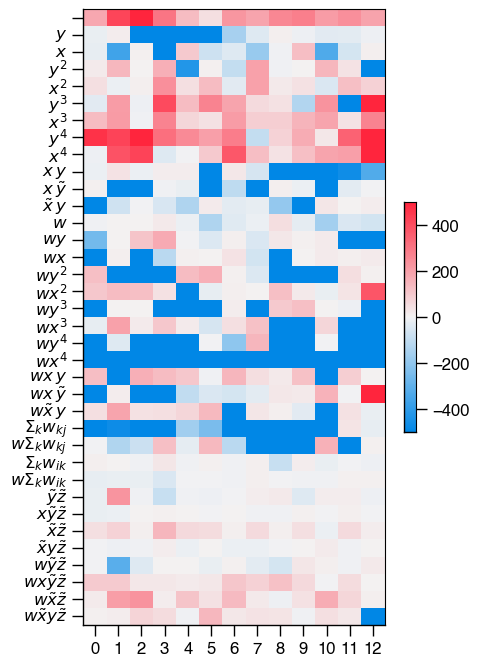

In [12]:
make_loss_plots(DATA_PATHS_NO_HET_LONG, num_terms=36)